# Classification fine des races

Dans cette partie, nous nous intéressons à la classification fine des 37 races de chiens et chats. Le modèle devra prédire à partir de l'image qu'on lui donne la race de chiens ou chats correspondante.

Nous testons des architectures CNN, à savoir une architecture "maison" puis un modèle ResNet50 pré-entraîné sur le dataset ImageNet. 

Nous entraînons notre modèle maison sur le dataset, tandis que nous utilisons du transfer learning pour calibrer ResNet50 à notre problème de classification.

La plan est le suivant : 
- Visualisations et comparaisons des losses
- Evaluations et comparaisons des accuracies
- Analyse des erreurs du meilleur modèle
- Interprétabilité avec Grad-CAM du meilleur modèle

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Présentation de notre modèle
Ce modèle nous sert de baseline pour évaluer l'efficacité du transfer learning avec ResNet50.


Notre modèle suit une approche classique avec 4 blocs convolutionnels successifs :

#### **4 Blocs Convolutionnels**
- **Bloc 1** : `3 → 32 canaux`
- **Bloc 2** : `32 → 64 canaux`
- **Bloc 3** : `64 → 128 canaux`
- **Bloc 4** : `128 → 256 canaux`

Chaque bloc utilise la structure : `Conv2D (3×3) → BatchNorm → ReLU → MaxPool2D (2×2)`

#### **Tête de Classification**
- **Pooling Global** : Réduit chaque feature map 256×16×16 à 256×1×1
- **FC1** : `256 → 512` avec ReLU et Dropout (50%)
- **FC2** : `512 → 37 classes` (sortie finale)

In [2]:
# Définition des chemins vers les résultats
results_paths = {
    'Baseline CNN': 'models/temp_results/classification_fine/baseline_simple_cnn',
    'Phase 1 (Head Only)': 'models/temp_results/classification_fine/phase1_head_only',
    'Phase 2 (Full Fine-tuning)': 'models/temp_results/classification_fine/phase2_full_finetuning'
}

# Chargement des loss logs
loss_data = {}
configs = {}

for name, path in results_paths.items():
    loss_path = Path(path) / 'loss_log.npy'
    config_path = Path(path) / 'config.yaml'
    
    if loss_path.exists():
        loss_data[name] = np.load(loss_path, allow_pickle=True).item()
    
    if config_path.exists():
        with open(config_path, 'r') as f:
            configs[name] = yaml.safe_load(f)

## Méthodologie d'entraînement pour ResNet50 (Transfer Learning)

Nous adoptons une stratégie en deux phases pour entraîner ResNet50 sur notre tâche de classification fine.
<div style="background-color: #d4edda; padding: 15px; border-left: 4px solid #28a745; margin: 15px 0;">
<h4><strong>Phase 1 (Head Fine-tuning)</strong></h4>
<ul>
    <li><strong>Objectif</strong> : Entraîner uniquement la tête de classification tout en gardant les poids pré-entraînés d'ImageNet fixes.</li>
    <li><strong>Avantage</strong> : Permet au modèle d'apprendre rapidement des caractéristiques spécifiques au dataset cible sans perturber les features générales déjà apprises.</li>
    <li><strong>Configuration</strong> : Taux d'apprentissage initial de 1e-3</li>
</ul>
</div>
<div style="background-color: #fff3cd; padding: 15px; border-left: 4px solid #ffc107; margin: 15px 0;">
<h4><strong>Phase 2 (Full Fine-tuning)</strong></h4>
<ul>
    <li><strong>Objectif</strong> : Affiner l'ensemble du modèle, y compris les couches convolutionnelles pré-entraînées.</li>
    <li><strong>Avantage</strong> : Permet au modèle d'ajuster les features générales aux spécificités du dataset cible, améliorant ainsi la performance.</li>
    <li><strong>Configuration</strong> : Taux d'apprentissage initial de 1e-4</li>
</ul>
</div>

## Comparaison Train vs Validation

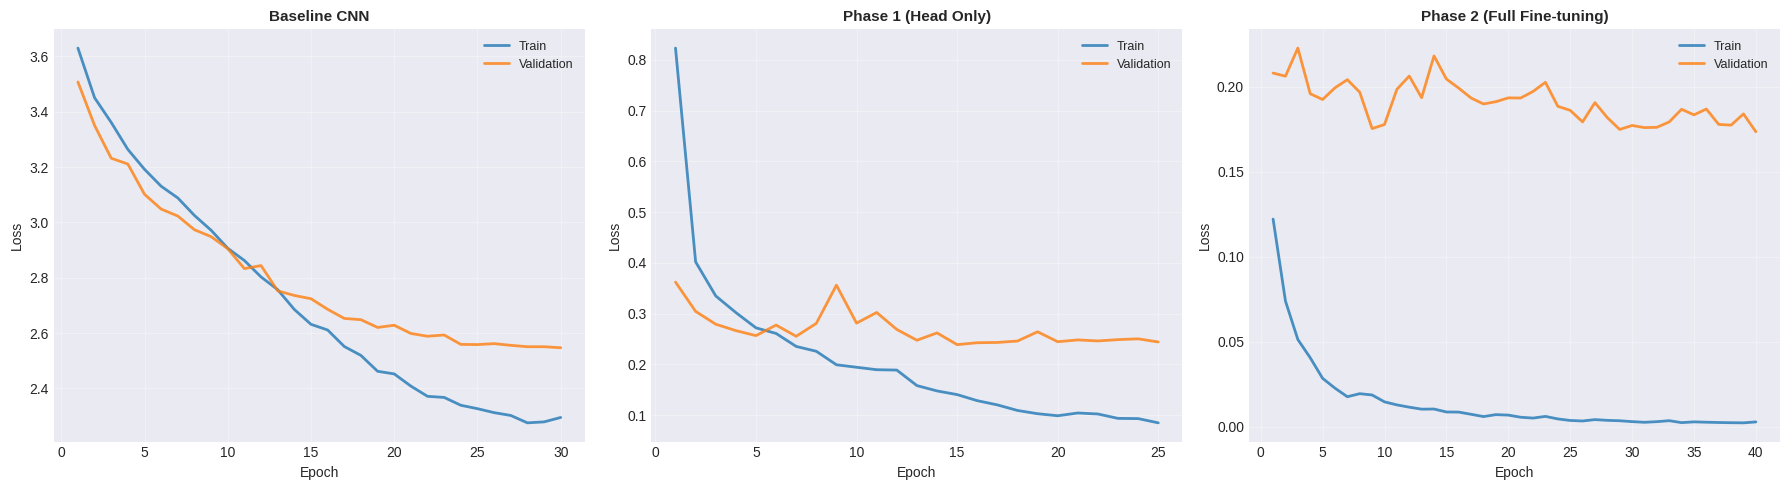

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(loss_data.items()):
    ax = axes[idx]
    
    if 'train' in data and 'val' in data:
        epochs = range(1, len(data['train']) + 1)
        ax.plot(epochs, data['train'], label='Train', linewidth=2, alpha=0.8)
        ax.plot(epochs, data['val'], label='Validation', linewidth=2, alpha=0.8)
        
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Loss', fontsize=10)
        ax.set_title(name, fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Évaluation des modèles sur le test set

In [4]:
import os
import sys
import torch
import torch.nn as nn
from dataloader_segmentation import get_oxford_loaders
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Importer les modèles depuis classification_models.py
sys.path.insert(0, 'models')
from classification_models import SimplePetCNN, ResNet50Pets

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<p>Les trois modèles présentent des comportements d'apprentissage distincts.</p>

<div style="background-color: #f8f9fa; padding: 15px; border-left: 4px solid #007bff; margin: 15px 0;">
<h4><strong>Baseline CNN</strong></h4>
<ul>
    <li><strong>Convergence lente</strong> : Les losses diminuent progressivement de ~3.6 à ~2.5</li>
    <li><strong>Gap train/validation modéré</strong> : Écart stable autour de 0.1-0.2, indiquant un léger overfitting</li>
    <li><strong>Plateau précoce</strong> : La validation stagne vers l'epoch 15, suggérant une capacité limitée</li>
</ul>
</div>

<div style="background-color: #e8f5e8; padding: 15px; border-left: 4px solid #28a745; margin: 15px 0;">
<h4><strong>Phase 1 (Head Only)</strong></h4>
<ul>
    <li><strong>Convergence rapide</strong> : Loss train chute drastiquement de 0.8 à ~0.1 en quelques epochs</li>
    <li><strong>Efficacité du transfer learning</strong> : Les features pré-entraînées ImageNet sont déjà pertinentes</li>
    <li><strong>Validation stable</strong> : Reste autour de 0.25-0.3, montrant une bonne généralisation</li>
</ul>
</div>

<div style="background-color: #fff3cd; padding: 15px; border-left: 4px solid #ffc107; margin: 15px 0;">
<h4><strong>Phase 2 (Full Fine-tuning)</strong></h4>
<ul>
    <li><strong>Performance optimale</strong> : Loss train descend proche de 0, validation vers 0.17, ce qui indique une très bonne performance malgré un léger overfitting</li>
</ul>
</div>

In [5]:
def evaluate_model(model, test_loader, device):
    """Évalue un modèle sur le test set et retourne predictions et labels"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    accuracy = (all_preds == all_labels).mean() * 100.0
    
    return all_preds, all_labels, accuracy

In [13]:
# Chargement et évaluation des modèles sauvegardés
model_results = {}

# Charger les loaders
loaders = get_oxford_loaders(
    root_dir='data/oxford-iiit-pet',
    task='classification_fine',
    batch_size=32
)
test_loader = loaders['test']

# Récupérer le mapping des labels
# Créer le mapping à partir des données du dataset
breed_to_label = {}
label_to_name = {}

# Parcourir le dataset pour extraire les breeds uniques
for idx in range(len(test_loader.dataset.df)):
    row = test_loader.dataset.df.iloc[idx]
    breed_name = row['breed']
    breed_id = row['breed_id']
    category = row['category']  # 0=Cat, 1=Dog
    
    # Calculer le label comme dans le dataset
    label = breed_id - 1 if category == 0 else 12 + breed_id - 1
    
    if label not in label_to_name:
        label_to_name[label] = breed_name
        breed_to_label[breed_name] = label

num_classes = len(label_to_name)

# 1. Baseline CNN
baseline_path = 'models/temp_results/classification_fine/baseline_simple_cnn/best.pth'
if os.path.exists(baseline_path):
    baseline_model = SimplePetCNN(num_classes=num_classes).to(DEVICE)
    baseline_model.load_state_dict(torch.load(baseline_path, map_location=DEVICE))
    
    preds, labels, accuracy = evaluate_model(baseline_model, test_loader, DEVICE)
    model_results['Baseline CNN'] = {
        'predictions': preds,
        'labels': labels,
        'accuracy': accuracy,
        'label_to_name': label_to_name,
        'num_classes': num_classes
    }
else:
    print("  → Modèle Baseline CNN non trouvé")

# 2. Phase 1 (Head Only)
phase1_path = 'models/temp_results/classification_fine/phase1_head_only/best.pth'
if os.path.exists(phase1_path):
    phase1_model = ResNet50Pets(num_classes=num_classes).to(DEVICE)
    phase1_model.load_state_dict(torch.load(phase1_path, map_location=DEVICE))
    
    preds, labels, accuracy = evaluate_model(phase1_model, test_loader, DEVICE)
    model_results['Phase 1 (Head Only)'] = {
        'predictions': preds,
        'labels': labels,
        'accuracy': accuracy,
        'label_to_name': label_to_name,
        'num_classes': num_classes
    }

# 3. Phase 2 (Full Fine-tuning)
phase2_path = 'models/temp_results/classification_fine/phase2_full_finetuning/best.pth'
if os.path.exists(phase2_path):
    phase2_model = ResNet50Pets(num_classes=num_classes).to(DEVICE)
    phase2_model.load_state_dict(torch.load(phase2_path, map_location=DEVICE))
    
    preds, labels, accuracy = evaluate_model(phase2_model, test_loader, DEVICE)
    model_results['Phase 2 (Full Fine-tuning)'] = {
        'predictions': preds,
        'labels': labels,
        'accuracy': accuracy,
        'label_to_name': label_to_name,
        'num_classes': num_classes
    }


## Comparaison des Accuracies

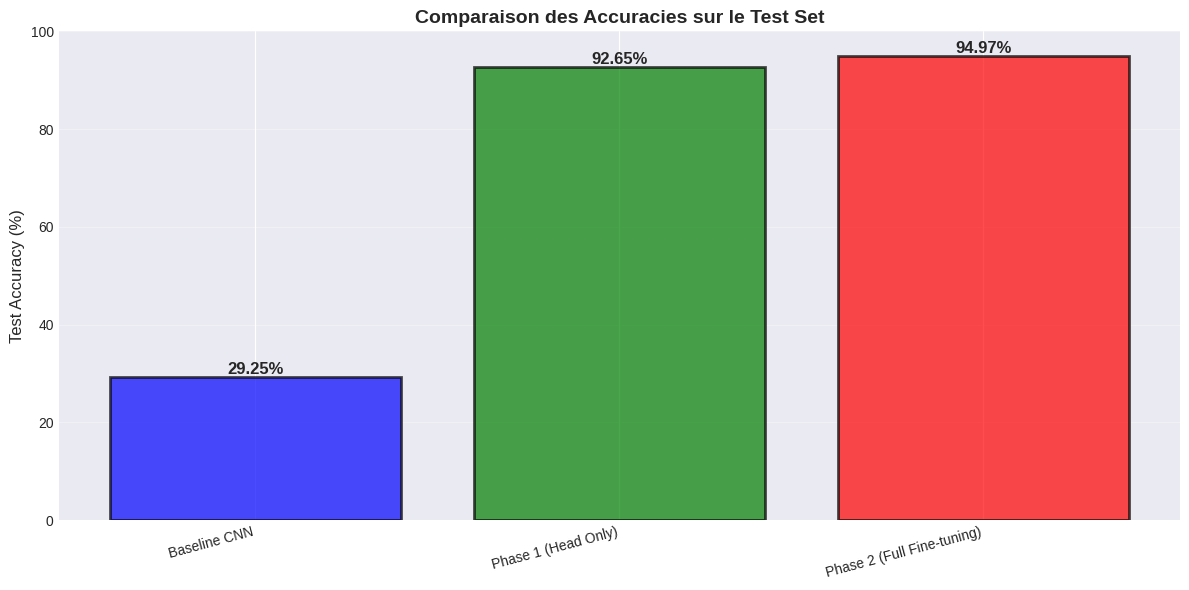

In [7]:
# Graphique de comparaison des accuracies
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(model_results.keys())
accuracies = [model_results[name]['accuracy'] for name in model_names]

bars = ax.bar(model_names, accuracies, color=['blue', 'green', 'red'], alpha=0.7, edgecolor='black', linewidth=2)

# Ajouter les valeurs sur les barres
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Comparaison des Accuracies sur le Test Set', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Comme on peut le voir, le modèle ResNet50 avec fine-tuning complet surpasse largement les autres modèles, atteignant une accuracy de 94.97%.**

**Le modèle avec seulement la tête fine-tunée atteint déjà une performance de 92.65%. En revanche, le modèle baseline CNN, entraîné from scratch, ne parvient qu'à une accuracy de 29.25%.**

## Matrice de confusion du meilleur modèle (ResNet50 Full Fine-tuning)

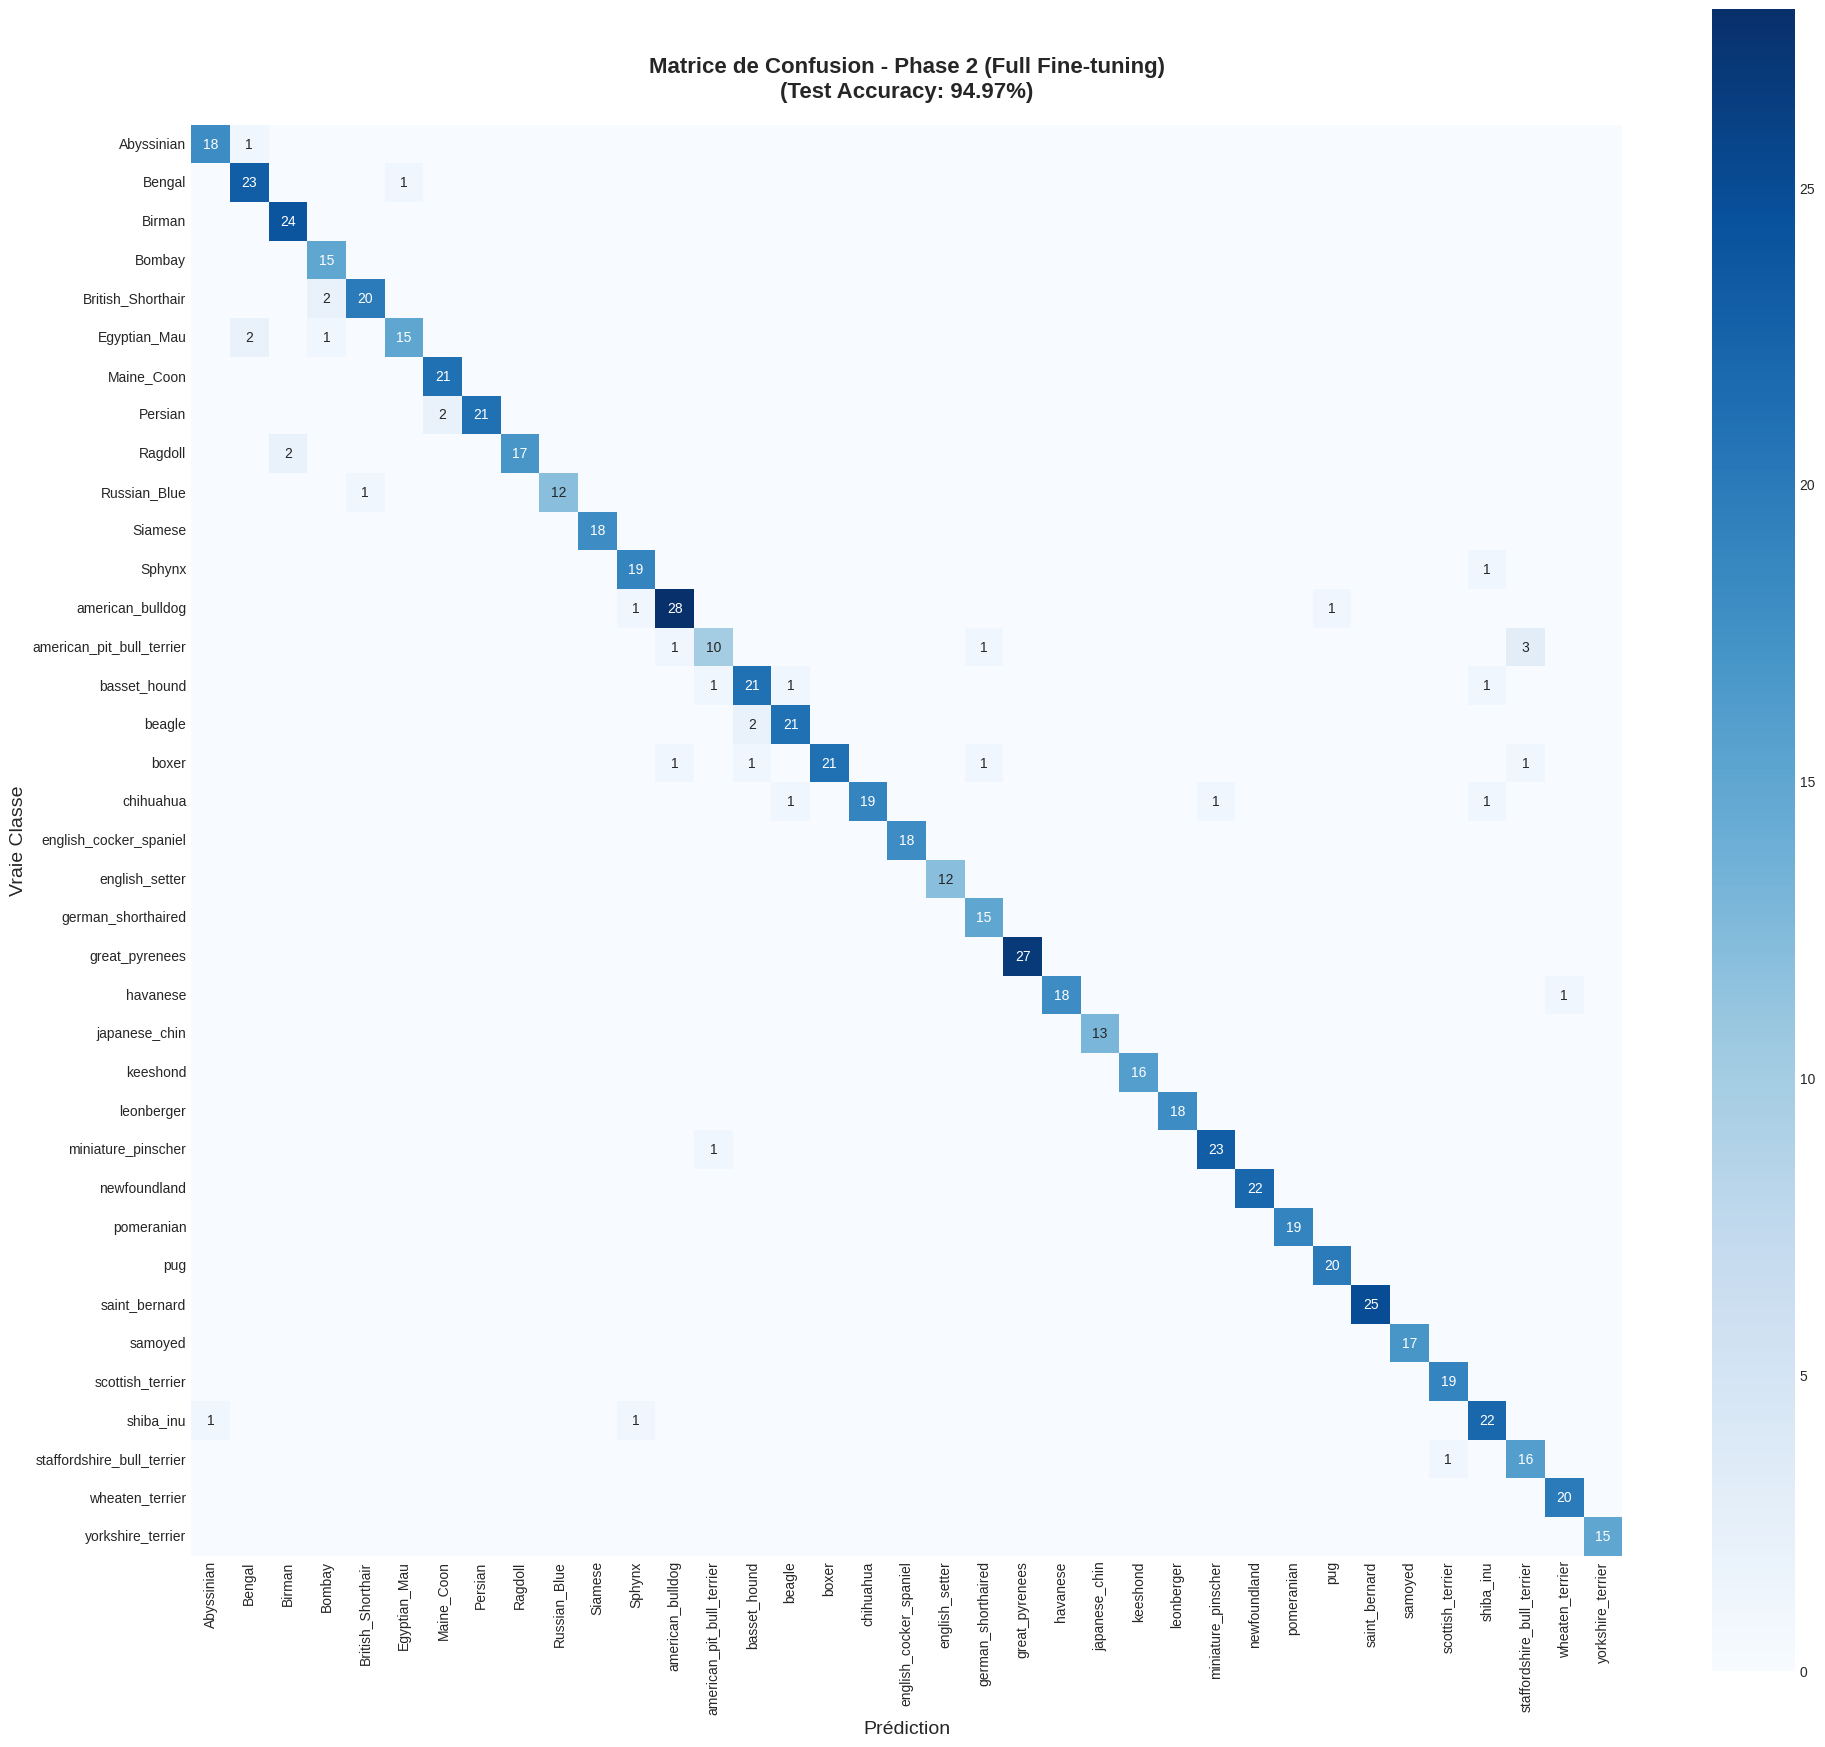

In [8]:
# Afficher une matrice de confusion détaillée pour chaque modèle
for model_name in model_names[2:]:
    results = model_results[model_name]
    preds = results['predictions']
    labels = results['labels']
    label_to_name = results['label_to_name']
    num_classes = results['num_classes']
    
    # Calculer la matrice de confusion
    cm = confusion_matrix(labels, preds)
    cm_annot = np.where(cm == 0, "", cm)
    
    # Créer les labels de classes
    class_names = [label_to_name.get(i, f"Class_{i}") for i in range(num_classes)]
    
    # Grande figure pour chaque modèle
    plt.figure(figsize=(20, 18))
    sns.heatmap(
        cm,
        annot=cm_annot,
        fmt="",
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        square=True
    )
    
    plt.xlabel('Prédiction', fontsize=14)
    plt.ylabel('Vraie Classe', fontsize=14)
    plt.title(f'Matrice de Confusion - {model_name}\n(Test Accuracy: {results["accuracy"]:.2f}%)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

**Comme on peut voir sur la matrice de confusion, le modèle est très performant sur la majorité des classes, avec des taux de classification corrects très élevés sauf pour quelques classes spécifiques où des confusions subsistent, que nous allons étudier dans la suite.**

## Analyse des classes les plus confondues

In [9]:
# Analyse des top 5 classes les plus confondues pour chaque modèle
print("="*80)
print("TOP 5 CLASSES LES PLUS CONFONDUES")
print("="*80)

for model_name in model_names[2:]:
    print(f"\n{model_name}")
    print("-" * 50)
    
    results = model_results[model_name]
    preds = results['predictions']
    labels = results['labels']
    label_to_name = results['label_to_name']
    
    # Calculer la matrice de confusion
    cm = confusion_matrix(labels, preds)
    
    # Extraire les confusions (hors diagonale)
    confusions = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:  # Pas sur la diagonale et au moins 1 erreur
                true_class = label_to_name.get(i, f"Class_{i}")
                pred_class = label_to_name.get(j, f"Class_{j}")
                confusions.append((true_class, pred_class, cm[i, j]))
    
    # Trier par nombre d'erreurs décroissant
    confusions.sort(key=lambda x: x[2], reverse=True)
    
    # Afficher les top 5
    print(f"{'Rang':<4} {'Vraie Classe':<20} {'→':<3} {'Prédite':<20} {'Erreurs':<8}")
    print("-" * 60)
    
    for rank, (true_class, pred_class, errors) in enumerate(confusions[:5], 1):
        print(f"{rank:<4} {true_class:<20} {'→':<3} {pred_class:<20} {errors:<8}")

TOP 5 CLASSES LES PLUS CONFONDUES

Phase 2 (Full Fine-tuning)
--------------------------------------------------
Rang Vraie Classe         →   Prédite              Erreurs 
------------------------------------------------------------
1    american_pit_bull_terrier →   staffordshire_bull_terrier 3       
2    British_Shorthair    →   Bombay               2       
3    Egyptian_Mau         →   Bengal               2       
4    Persian              →   Maine_Coon           2       
5    Ragdoll              →   Birman               2       


**On remarque que certaines classes sont confondues car les espèces se ressemblent beaucoup visuellement (American Staffordshire Terrier et Staffordshire Bull Terrier, Egyptian Mau et Bengal, Ragdoll et Birman). Par contre, British Shorthair et Bombay ou bien Persian et Maine Coon sont des confusions plus surprenantes. Mais ces erreurs représentent une minorité des cas, ce qui montre que le modèle est globalement performant.**

## Analyse d'interprétabilité avec Grad-CAM

Dans cette section, nous analysons les erreurs du meilleur modèle (ResNet50 Full Fine-tuning) en utilisant Grad-CAM pour visualiser sur quelles parties de l'image le modèle se concentre lors de ses prédictions incorrectes. Et on regarde aussi les bonnes prédictions pour comprendre ce qui fonctionne bien.

In [30]:
# Identifier les images mal classées du meilleur modèle
best_model_name = 'Phase 2 (Full Fine-tuning)'
best_results = model_results[best_model_name]

predictions = best_results['predictions']
true_labels = best_results['labels']
label_to_name = best_results['label_to_name']

# Trouver les indices des erreurs
error_indices = np.where(predictions != true_labels)[0]

# Prendre un échantillon des erreurs les plus intéressantes
np.random.seed(42)
sample_errors = np.random.choice(error_indices, min(8, len(error_indices)), replace=False)

for i, idx in enumerate(sample_errors):
    true_class = label_to_name[true_labels[idx]]
    pred_class = label_to_name[predictions[idx]]

GRAD-CAM - IMAGES BIEN CLASSÉES


/home/zanni/.conda/envs/HDDLtorch/lib/python3.12/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


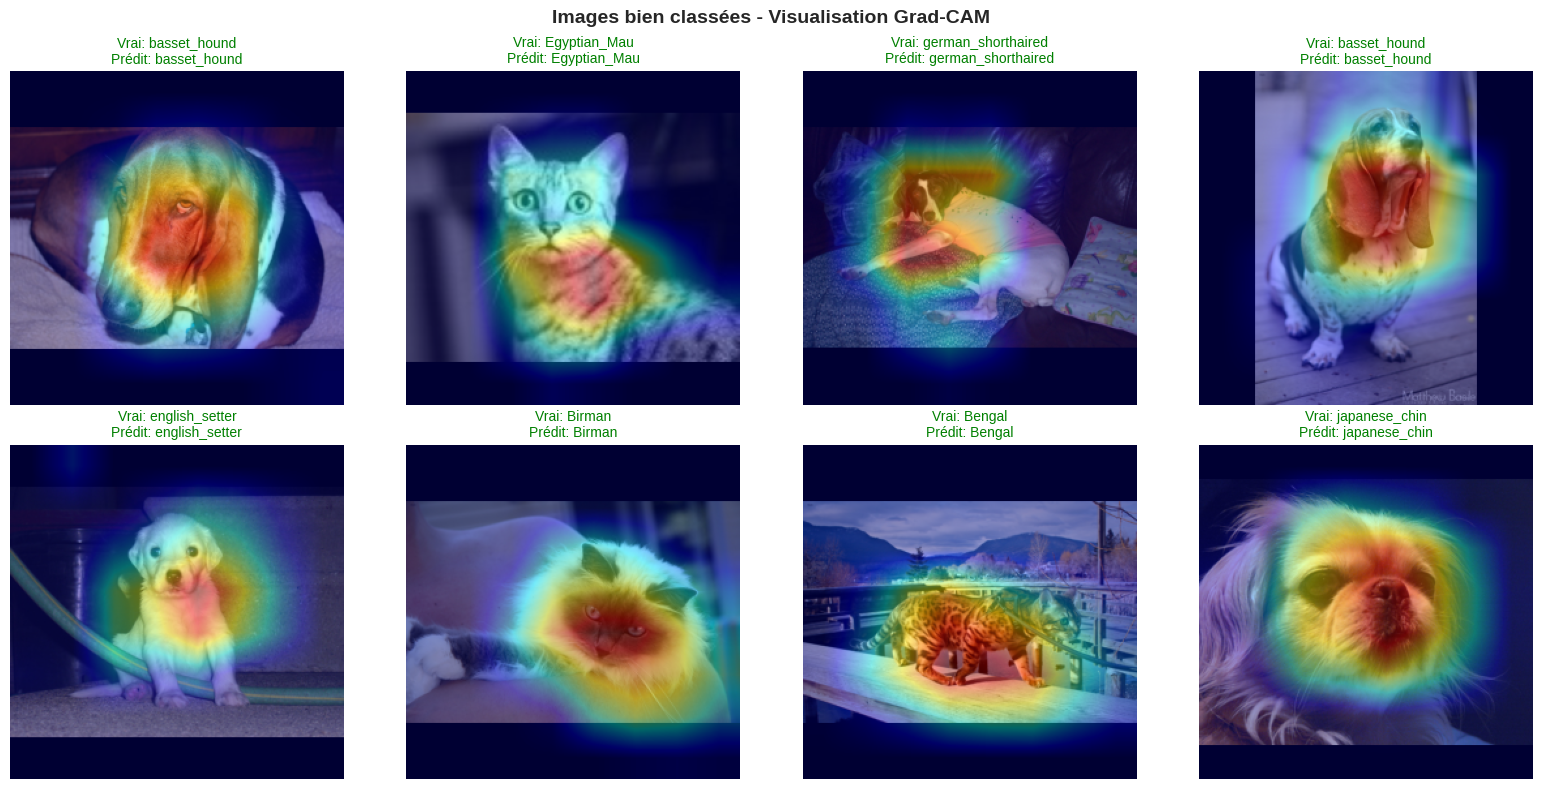


GRAD-CAM - IMAGES MAL CLASSÉES


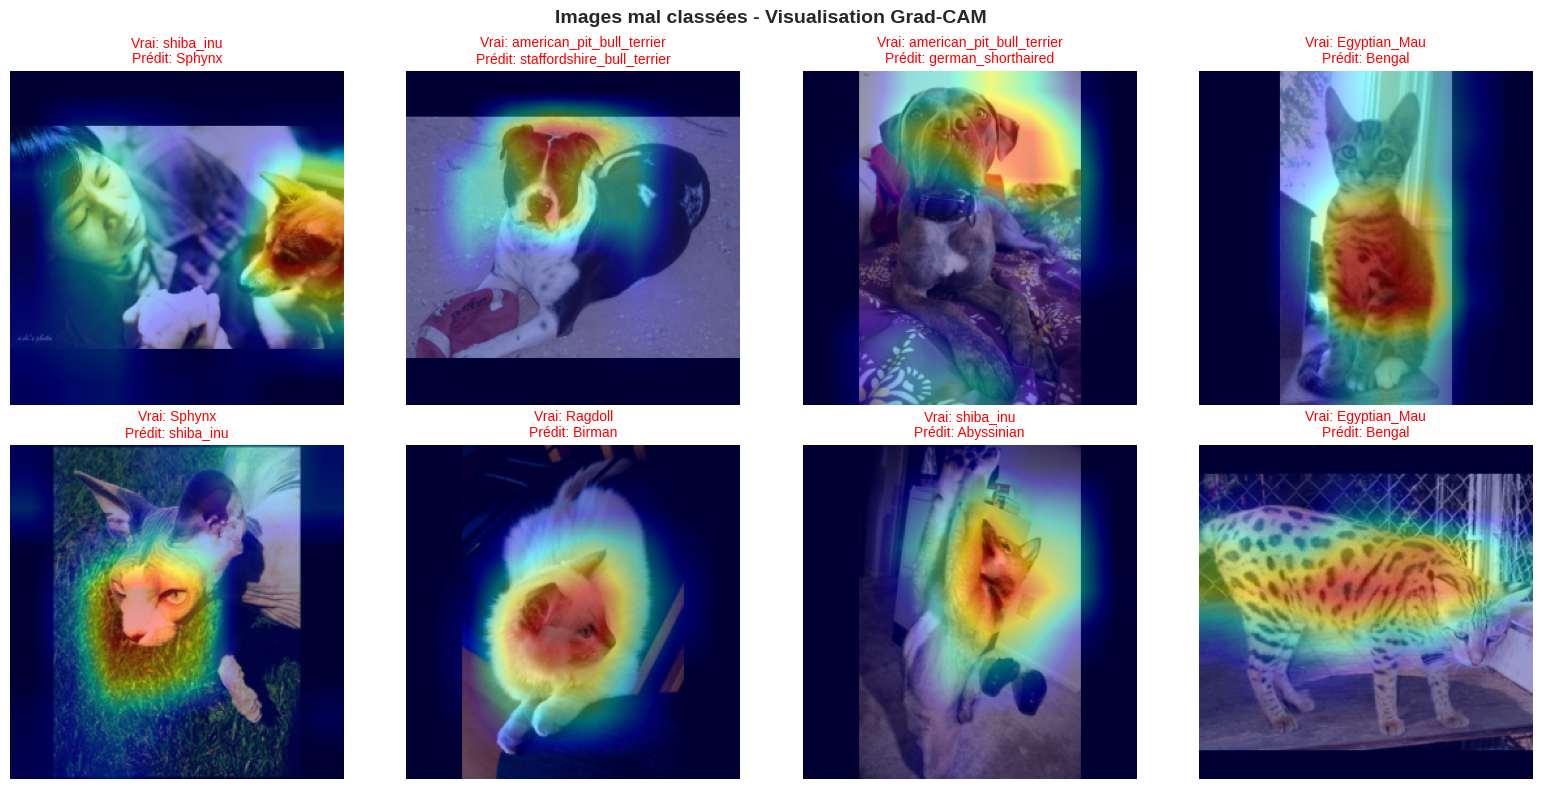

In [31]:
import cv2
from PIL import Image

import torch.nn.functional as F
import torchvision.transforms as transforms

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        
        # Hook pour capturer les gradients et activations
        hook1 = self.target_layer.register_forward_hook(self.save_activation)
        hook2 = self.target_layer.register_full_backward_hook(self.save_gradient)
        self.hooks.extend([hook1, hook2])
    
    def save_activation(self, module, input, output):
        self.activations = output
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
    
    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()
    
    def generate_cam(self, input_image, class_idx):
        # Ensure gradients are enabled for input
        input_image.requires_grad_(True)
        
        # Forward pass
        model_output = self.model(input_image)
        
        # Backward pass pour la classe cible
        self.model.zero_grad()
        model_output[0, class_idx].backward()
        
        # Vérifier que les gradients ont été capturés
        if self.gradients is None:
            print("Warning: No gradients captured!")
            return torch.zeros((224, 224), device=input_image.device)
        
        # Calcul du Grad-CAM
        gradients = self.gradients[0]
        activations = self.activations[0]
        
        # Pondération des cartes d'activation par les gradients
        weights = torch.mean(gradients, dim=[1, 2])
        
        # Combinaison pondérée des cartes d'activation - ensure same device
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        # Application de ReLU et normalisation
        cam = F.relu(cam)
        cam = cam / torch.max(cam) if torch.max(cam) > 0 else cam
        
        return cam

# Initialiser Grad-CAM pour le meilleur modèle
best_model = phase2_model
target_layer = best_model.resnet.layer4[-1].conv2  # Dernière couche conv avant le pooling

gradcam = GradCAM(best_model, target_layer)

# Fonction pour visualiser les résultats
def visualize_gradcam_results(images, predictions, true_labels, indices, title_prefix):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i, idx in enumerate(indices):
        if i >= 8:
            break
            
        row = i // 4
        col = i % 4
        
        # Récupérer l'image originale du dataset
        image_tensor, label = test_loader.dataset[idx]
        image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
        
        # Générer Grad-CAM pour la prédiction
        predicted_class = predictions[idx]
        cam = gradcam.generate_cam(image_tensor, predicted_class)
        
        # Convertir l'image pour l'affichage
        image_np = image_tensor.squeeze().cpu().detach().permute(1, 2, 0).numpy()
        image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
        # Clamp values to avoid clipping warnings
        image_np = np.clip(image_np, 0.0, 1.0)
        
        # Redimensionner la carte CAM à la taille de l'image
        cam_np = cam.detach().cpu().numpy()
        cam_resized = cv2.resize(cam_np, (image_np.shape[1], image_np.shape[0]))
        
        # Superposer la carte de chaleur sur l'image
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        
        superimposed = 0.6 * image_np + 0.4 * heatmap
        # Clamp final result to avoid clipping warnings
        superimposed = np.clip(superimposed, 0.0, 1.0)
        
        axes[row, col].imshow(superimposed)
        
        true_class_name = label_to_name[true_labels[idx]]
        pred_class_name = label_to_name[predictions[idx]]
        
        if true_labels[idx] == predictions[idx]:
            color = 'green'
        else:
            color = 'red'
            
        axes[row, col].set_title(
            f"Vrai: {true_class_name}\nPrédit: {pred_class_name}", 
            fontsize=10, color=color
        )
        axes[row, col].axis('off')
    
    # Masquer les axes non utilisés
    for i in range(len(indices), 8):
        row = i // 4
        col = i % 4
        axes[row, col].axis('off')
    
    plt.suptitle(f'{title_prefix} - Visualisation Grad-CAM', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 1. Visualiser des exemples bien classés
correct_indices = np.where(predictions == true_labels)[0]
np.random.seed(42)
sample_correct = np.random.choice(correct_indices, min(8, len(correct_indices)), replace=False)

print("="*60)
print("GRAD-CAM - IMAGES BIEN CLASSÉES")
print("="*60)

visualize_gradcam_results(None, predictions, true_labels, sample_correct, "Images bien classées")

# 2. Visualiser des exemples mal classés
print("\n" + "="*60)
print("GRAD-CAM - IMAGES MAL CLASSÉES")
print("="*60)

visualize_gradcam_results(None, predictions, true_labels, sample_errors, "Images mal classées")

**On remarque que le réseau s'attarde surtout sur les têtes des animaux pour déterminer la classe à laquelle il appartient, ou bien à son pelage, ce qui semble logique et assez similaire à ce que ferait un humain.**

**Par exemple, pour le Basset, il regarde les oreilles ou le regard qui sont caractéristiques de cette race.**

**On voit aussi qu'il confond Egyptian Mau et Bengal car il regarde le pelage, comme les deux pelages sont tâchetés et similaires, il lui arrive de confondre les deux.**